### Investigate extreme cases

##### 1. Reproduce example presented during the lecture (drug survey). 

In [1]:
import arviz as az
import pymc as pm  
import numpy as np

def generate_deterministic_model_samples(n_samples, yes_count):
    with pm.Model() as model:
        p_d = pm.Uniform("p_d", 0, 1)

        p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)

        answers = pm.Binomial("answers", n=n_samples, p=p_observed, observed=yes_count)

        idata = pm.sample(2000, tune=2500, return_inferencedata=True)

    az.plot_trace(idata, var_names=["p_d", "p_observed"], show=True)
    return idata

##### 2. See what happens when the number of “yes” answers (out of 100) is 
- 20 

Initializing NUTS using jitter+adapt_diag...
c:\Users\Filip\Documents\mgr-siium\metody_probabilistycznej_analizy_danych\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 10 seconds.


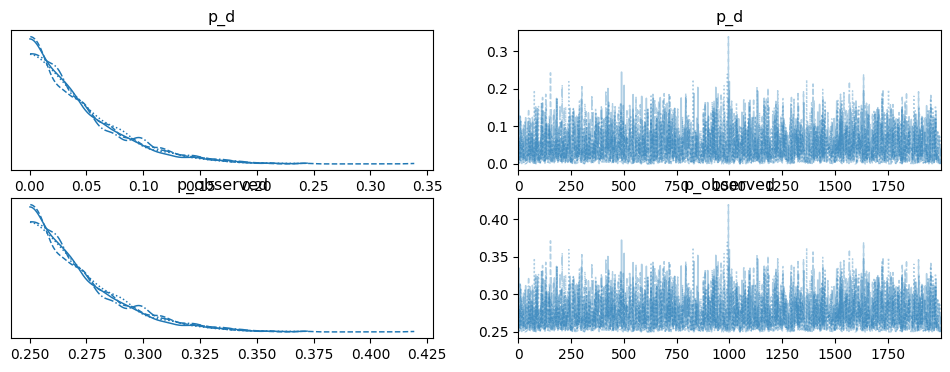

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [2]:
generate_deterministic_model_samples(100, 20)

- 10 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 10 seconds.


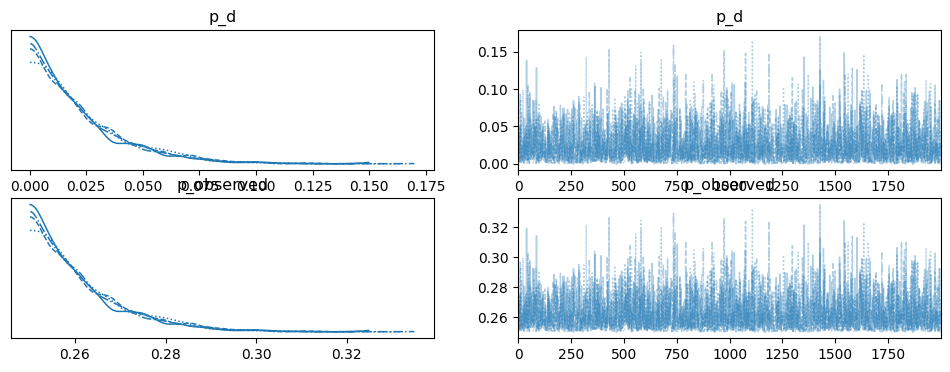

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [3]:
generate_deterministic_model_samples(100, 10)

- 5 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 15 seconds.


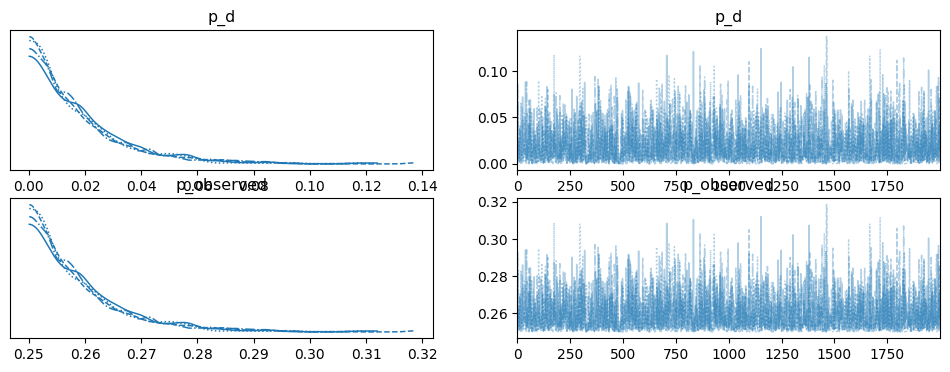

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [4]:
generate_deterministic_model_samples(100, 5)

Explain.

- Niezależnie od ilości odpowiedzi "TAK" wykresy osiągają swoje maksima p_observed w około 0.25, ponieważ wszystkie odpowiedzi są ponieżej 25 czyli wielkości 0.25 populacji 
- im mniej odpowiedzi "TAK", tym szybciej wykresy zbliżają się do osi X, co oznacza zwiększoną pewność estymacji
- im mniej odpowiedzi "TAK", tym bardziej skoncentrowany rozkład


### Generate sample data

##### 1. Modify previous example in order to obtain a sample datasets:

In [5]:
def generate_deterministic_model_probability(n_samples, probability_yes):
    yes_count = int(n_samples * probability_yes)

    with pm.Model() as model:
        p_d = pm.Uniform("p_d", 0, 1)

        p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)

        answers = pm.Binomial("answers", n=n_samples, p=p_observed, observed=yes_count)

        idata = pm.sample(2000, tune=2500, return_inferencedata=True)

    az.plot_trace(idata, var_names=["p_d", "p_observed"], show=True)
    return idata

- Generate a set of 100 answers for probability of a randomly chosen student taking drugs equal to: 0.1; 0.5; 0.9

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 10 seconds.


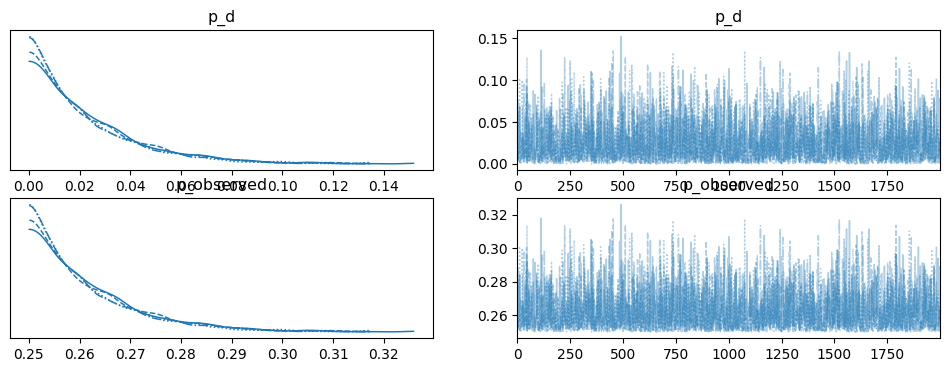

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [6]:
generate_deterministic_model_probability(100, 0.1)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 10 seconds.


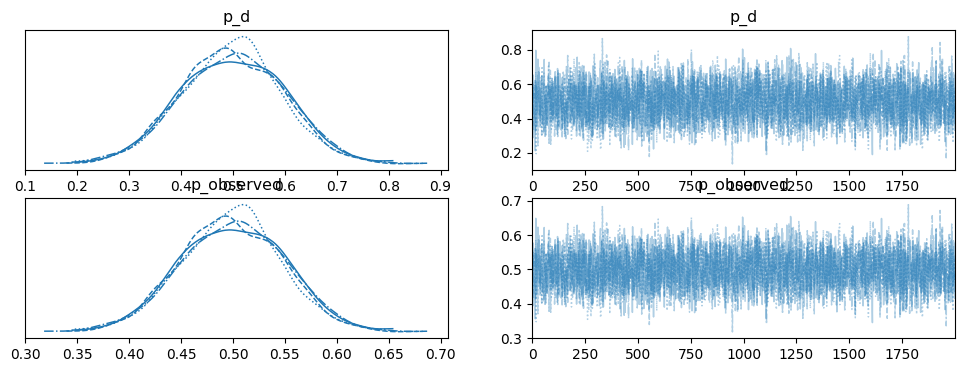

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [7]:
generate_deterministic_model_probability(100, 0.5)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 10 seconds.


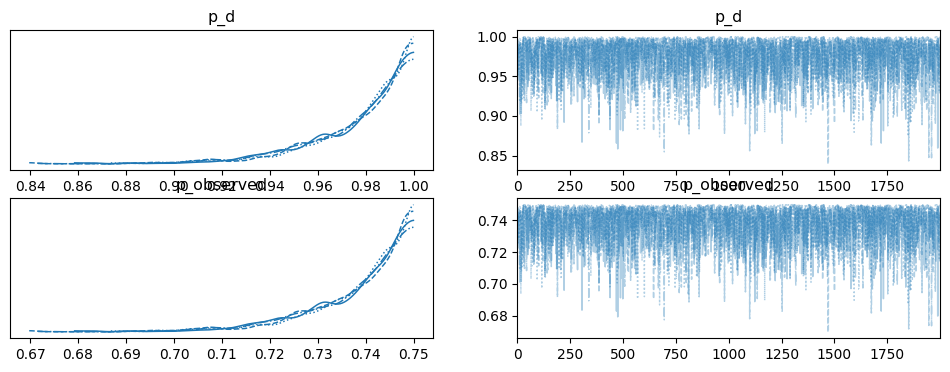

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [8]:
generate_deterministic_model_probability(100, 0.9)

- Set the probability of a randomly chosen student taking drugs at 0.1, count of the group at 100. The survey was repeated 50 times, generate number of “yes” answers for each attempt.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]
Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 10 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]
Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 13 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]
Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 17 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]
Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 10 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_d]
Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws

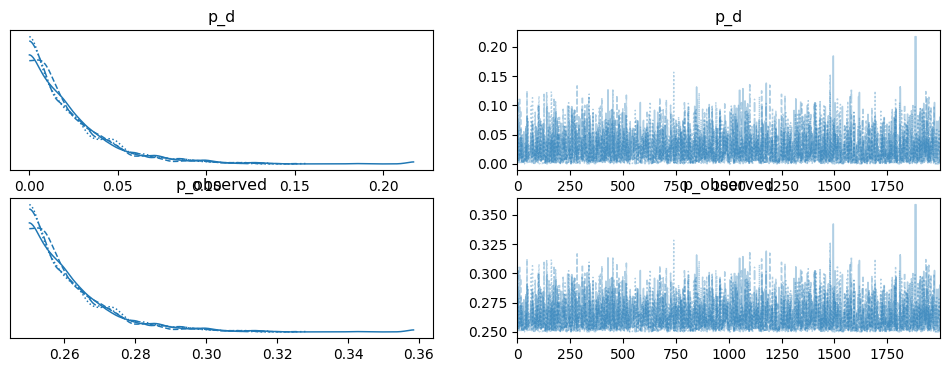


Number of 'yes' answers: [9, 13, 9, 11, 10, 9, 17, 12, 15, 8, 14, 14, 10, 8, 7, 7, 8, 11, 9, 9, 8, 7, 13, 12, 10, 8, 11, 11, 11, 11, 7, 14, 8, 10, 7, 4, 11, 6, 6, 12, 15, 9, 11, 5, 12, 11, 12, 12, 6, 11]
Mean: 10.02
Std: 2.77


In [ ]:
p_drugs = 0.1
n_students = 100
n_attempts = 50


def generate_multiple_surveys(n_samples, probability, n_attempts):
    yes_counts = []
    idata_results = []
    
    for attempt in range(n_attempts):
        yes_count = np.random.binomial(n=n_samples, p=probability)
        
        with pm.Model() as model:
            p_d = pm.Uniform("p_d", 0, 1)
            p_observed = pm.Deterministic("p_observed", 0.25 + 0.5 * p_d)
            answers = pm.Binomial("answers", n=n_samples, p=p_observed, observed=yes_count)
            idata = pm.sample(2000, tune=2500, return_inferencedata=True, progressbar=False)
        
        yes_counts.append(yes_count)
        idata_results.append(idata)
    
    az.plot_trace(idata_results[-1], var_names=["p_d", "p_observed"], show=True)
    
    return yes_counts, idata_results

yes_counts, results = generate_multiple_surveys(n_students, p_drugs, n_attempts)
print(f"\nNumber of 'yes' answers: {yes_counts}")
print(f"Mean: {np.mean(yes_counts):.2f}")
print(f"Std: {np.std(yes_counts):.2f}")

**Wnioski**

- im bliżej skrajnych wartości tym model jest pewniejszy że czegoś najprawdopodobniej wcale nie ma (dla p=0.1 p_d jest największe w 0) lub jest pewny że jest (dla 0.9 p_d jest największe w 1) 
- dla 0.5 p_d jest bardzo rozłożont i zawiera wartości od 0 do 1
- Rozrzut wyników pokazuje, że pojedyncze badanie może wprowadzać duży błąd
- Wspólna analiza wielu prób zmniejsza wariancję estymacji p_d -> im więcej badań, tym pewniejsze wnioski o p_d